In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

## Find grid sizes

In [ ]:
# Temporary
# side_lengths = np.array(
#     [
#         0.2,
#         0.135,
#         0.108,
#         0.094,
#         0.0831,
#         0.075,
#         0.07,
#         0.065,
#         0.061,
#         0.0581,
#         0.04,
#         0.03,
#         0.01,
#     ]
# )


In [3]:
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids.pkl"
)

if MODE_GRIDS_FILENAME.exists():
    # Load existing mode grids
    with MODE_GRIDS_FILENAME.open("rb") as f:
        mode_grids = pickle.load(f)
    print("Mode grid successfully loaded")
else:
    # Generate new mode grids
    side_lengths = np.array(
        [
            0.2,
            0.135,
            0.108,
            0.094,
            0.0831,
            0.075,
            0.07,
            0.065,
            0.061,
            0.0581,
        ]
    )
    mode_grids = []

    for side_length in side_lengths:
        my_grid = mode_grid_factory.from_tiling(
            tiling_type="rectangles",
            side_length=(side_length, side_length),
            r_lim=1.2,
            grid_wave_type="propagating",
            rotation_angle=0.0,
            translation_vector=np.array([0.0, 0.0]),
        )
        print(f"{side_length}: {my_grid.num_propagating}")
        mode_grids.append(my_grid)

    with MODE_GRIDS_FILENAME.open("wb") as f:
        pickle.dump(mode_grids, f)
    print("Mode grid generation successful")

num_modes = [grid.num_propagating for grid in mode_grids]

Mode grid successfully loaded


In [4]:
first = [
    "pp,pp",
    "pp,pe",
    "pp,ep",
    "pp,ee",
    "pe,pe",
    "pe,pe",
    "pe,ep",
    "pe,ee",
    "ep,ep",
    "ep,ee",
    "ee,ee",
]
second = [
    "t,t",
    "t,r",
    "t,t2",
    "t,r2",
    "r,r",
    "r,t2",
    "r,r2",
    "t2,t2",
    "t2,r2",
    "r2,r2",
]

## 2D vs 3D Tests

In [9]:
wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

# 2D version
particle_statistics_2d = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics_2d = MediumStatistics([particle_statistics_2d])

# 3D version
particle_statistics_3d = ParticleStatistics(
    term,
    isotropic_sphere.get_A_3d,
    isotropic_sphere.get_A_product_3d,
    isotropic_sphere.get_A_product_conj_3d,
)
medium_statistics_3d = MediumStatistics([particle_statistics_3d])

# Non GPU Config
use_np_config = IntegrationTaskConfig(use_gpu=False)
use_cp_config = IntegrationTaskConfig(use_gpu=True)

In [10]:
indices = [0]

data_2d_np = []
data_2d_cp = []
data_3d_np = []
data_3d_cp = []

time_2d_np = []
time_2d_cp = []
time_3d_np = []
time_3d_cp = []

for side_length in tqdm.tqdm(side_lengths[indices]):
    print("------------")
    print(f"Side lentgh = {side_length}")
    print("------------")

    # Define grid
    my_grid = mode_grid_factory.from_tiling(
        tiling_type="rectangles",
        side_length=(side_length, side_length),
        r_lim=1.2,
        grid_wave_type="propagating",
        rotation_angle=0.0,
        translation_vector=np.array([0.0, 0.0]),
    )

    # Set up the relevant indices
    propagating_indices = my_grid.propagating_indices
    quads = [(0, i, 0, i) for i in propagating_indices]
    supplied_indices = {
        "covariance": {key1: {key2: [] for key2 in second} for key1 in first}
    }
    for key in ["t,t"]:
        supplied_indices["covariance"]["pp,pp"][key] = quads

    # 2D NUMPY
    simulation_name = f"2d_np_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics_2d,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=True,
        integration_method="cubature",
        covariance_cubature_scheme=None,
        integration_task_config=use_np_config,
    )
    integration_result_list, duration = (
        input_statistics_manager.get_statistics()
    )
    data_2d_np.append(integration_result_list)
    time_2d_np.append(duration)

    # 2D CUPY
    simulation_name = f"2d_cp_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics_2d,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=False,
        integration_method="cubature",
        covariance_cubature_scheme=None,
        integration_task_config=use_cp_config,
    )
    integration_result_list, duration = (
        input_statistics_manager.get_statistics()
    )
    data_2d_cp.append(integration_result_list)
    time_2d_cp.append(duration)

    # 3D NUMPY
    simulation_name = f"3d_np_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics_3d,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=False,
        integration_method="cubature",
        covariance_cubature_scheme=None,
        integration_task_config=use_np_config,
    )
    integration_result_list, duration = (
        input_statistics_manager.get_statistics()
    )
    data_3d_np.append(integration_result_list)
    time_3d_np.append(duration)

    # 3D CUPY
    simulation_name = f"3d_cp_{side_length}"
    input_statistics_manager = InputStatisticsManager(
        simulation_name,
        medium_parameters,
        medium_statistics_3d,
        my_grid,
        supplied_indices=supplied_indices,
        use_dirac_density=False,
        integration_method="cubature",
        covariance_cubature_scheme=None,
        integration_task_config=use_cp_config,
    )
    integration_result_list, duration = (
        input_statistics_manager.get_statistics()
    )
    data_3d_cp.append(integration_result_list)
    time_3d_cp.append(duration)

  0%|          | 0/1 [00:00<?, ?it/s]

------------
Side lentgh = 0.2
------------


/tmp/ipykernel_678519/3841081425.py:39: UserWarning: No parent_data_dir provided. Defaulting to current working directory: /home/nbyrnes/code/random-matrix/data.
  input_statistics_manager = InputStatisticsManager(


[08/23 16:05:04] Classify singles


100%|██████████| 101/101 [00:00<00:00, 1783.50it/s]

...


100%|██████████| 101/101 [00:00<00:00, 6502.20it/s]

[08/23 16:22:25] Done
[08/23 16:22:25] Prepare covariance tasks



100%|██████████| 47/47 [00:10<00:00,  4.57it/s]


[08/23 16:22:38] Done


100%|██████████| 1/1 [17:35<00:00, 1055.47s/it]


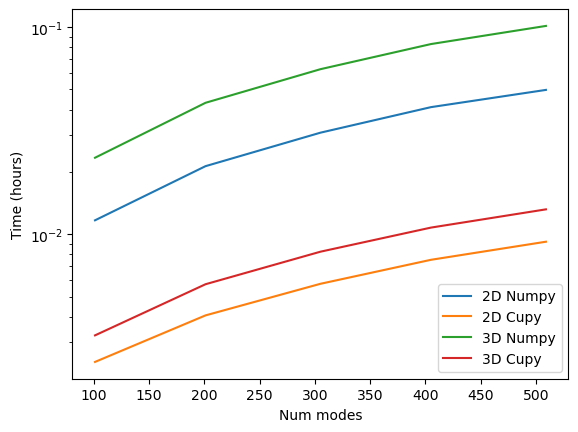

In [ ]:
# Time graph
total_2d_np = np.array(time_2d_np) / 60**2
total_2d_cp = np.array(time_2d_cp) / 60**2
total_3d_np = np.array(time_3d_np) / 60**2
total_3d_cp = np.array(time_3d_cp) / 60**2
x = np.array(num_modes)

fig, ax = plt.subplots()
ax.plot(x, total_2d_np, label="2D Numpy")
ax.plot(x, total_2d_cp, label="2D Cupy")
ax.plot(x, total_3d_np, label="3D Numpy")
ax.plot(x, total_3d_cp, label="3D Cupy")

ax.set_yscale("log")
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()

In [ ]:
# Find the index for (0,0,0,0)
zero_indices = []
for data_array in data_2d_np:
    for i, r in enumerate(data_array.results):
        if r.sub_block_locations[0] == (0, 0, 0, 0):
            index = i
            zero_indices.append(index)
            break
print(zero_indices)

[21, 72, 58, 120, 160]


In [ ]:
errs = []

trues = []
norms_true = []
converts = []
norms_convert = []

for index, my_grid, r_list_2d, r_list_3d in zip(
    zero_indices, mode_grids, data_2d_np, data_3d_np
):
    r_2d = r_list_2d.results[index].integral
    r_3d = r_list_3d.results[index].integral

    r_2d_square = r_2d.reshape((4, 4))
    r_3d_square = r_3d.reshape((9, 9))

    # Convert r_3d to a 2x2 matrix
    P = scattering_geometry.get_two_to_three_matrices(
        np.array([0.0]), np.array([0.0]), np.array([1.0])
    )[0]
    pre = np.kron(P, P)
    post = np.kron(P.T, P.T)
    r_2d_from_3d = pre @ r_3d_square @ post

    norm_true = np.linalg.norm(r_2d_square)
    norm_convert = np.linalg.norm(r_2d_from_3d)
    # print(norm_true)
    print(norm_convert)

    trues.append(r_2d_square)
    converts.append(r_2d_from_3d)

    # Save differences
    difference = np.linalg.norm(r_2d_square - r_2d_from_3d) / max(
        norm_true, norm_convert
    )
    errs.append(difference)

6.408768242862011e-07
6.101183372911701e-08
1.6022997627680762e-08
6.971084812388468e-09
3.3293780475090702e-09


/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:30: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:44: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


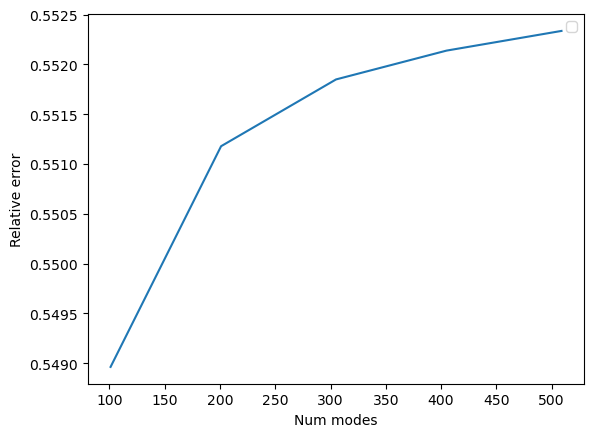

In [ ]:
# Time graph
fig, ax = plt.subplots()
ax.plot(x, errs)
ax.set_ylabel("Relative error")
ax.set_xlabel("Num modes")
ax.legend()

## Different integration methods